# Pipeline Final — Copa FutBotMX
## Visión por Computadora: Segmentación, Tracking y Análisis Táctico

**Equipo:** *Los más 3D*  
**Categoría:** Amateur  
**Video procesado:** Vista cenital con cámara fija

Este notebook integra el pipeline completo:
1. **YucaBot** (YOLOv8m fine-tuned) para detección de robots y balón
2. **SAM 3** para segmentación con máscaras precisas
3. **ByteTrack** para tracking continuo entre frames
4. **Mapa táctico** con proyección geométrica y vista cenital
5. **Visualizaciones** de heatmap y trayectorias


In [38]:
import warnings
warnings.filterwarnings("ignore")

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import supervision as sv
import torch
from pathlib import Path
from ultralytics import YOLO, SAM
from ultralytics.models.sam import SAM3SemanticPredictor

Path("assets").mkdir(exist_ok=True)

print(f"Supervision: {sv.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Supervision: 0.28.0
PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: NVIDIA GeForce RTX 5050


## 1. Configuración global

In [39]:
# ── Rutas ─────────────────────────────────────────────────────────────────
VIDEO_PATH     = "../VideosEjemplo/Cenital3.mp4"
OUTPUT_PIPELINE = "assets/pipeline_final.mp4"
OUTPUT_HEATMAP  = "assets/heatmap_final.png"
OUTPUT_TRAILS   = "assets/trails_final.png"

# ── Campo canónico (vista cenital) ─────────────────────────────────────────
# Dimensiones en píxeles del mapa táctico (basadas en cancha real FutBotMX)
CAMPO_W, CAMPO_H = 810, 1080
ESCALA_PX_CM = 4.0  # 1 cm real = 4 px en el campo canónico

TARGET_POINTS = np.float32([
    [0,       0      ],  # TL
    [CAMPO_W, 0      ],  # TR
    [CAMPO_W, CAMPO_H],  # BR
    [0,       CAMPO_H],  # BL
])

# ── Puntos SOURCE en el video cenital.mp4 (vista cenital fija) ───────────────
# Estos puntos corresponden a las 4 esquinas de la cancha en el video
# Ajusta si usas un video distinto
SOURCE_POINTS = np.float32([
    [ 200,  240],   # esquina superior-izquierda
    [1070,   250],   # esquina superior-derecha
    [1050, 1790],   # esquina inferior-derecha
    [ 50,  1550],   # esquina inferior-izquierda
])

# ── Colores por clase (BGR) ────────────────────────────────────────────────
# class 0 = ball, class 1 = robot
COLORS_BGR = {
    0: (0,   200, 255),   # balón  → naranja
    1: (239,  35,  60),   # robot  → rojo/azul alternado por tracker_id
}

# Calcular matriz de homografía
H_matrix = cv2.getPerspectiveTransform(SOURCE_POINTS, TARGET_POINTS)
print("✓ Configuración lista")
print(f"  Campo canónico: {CAMPO_W}×{CAMPO_H} px")
print(f"  Matriz H calculada")


✓ Configuración lista
  Campo canónico: 810×1080 px
  Matriz H calculada


## 2. Verificar puntos SOURCE sobre el video

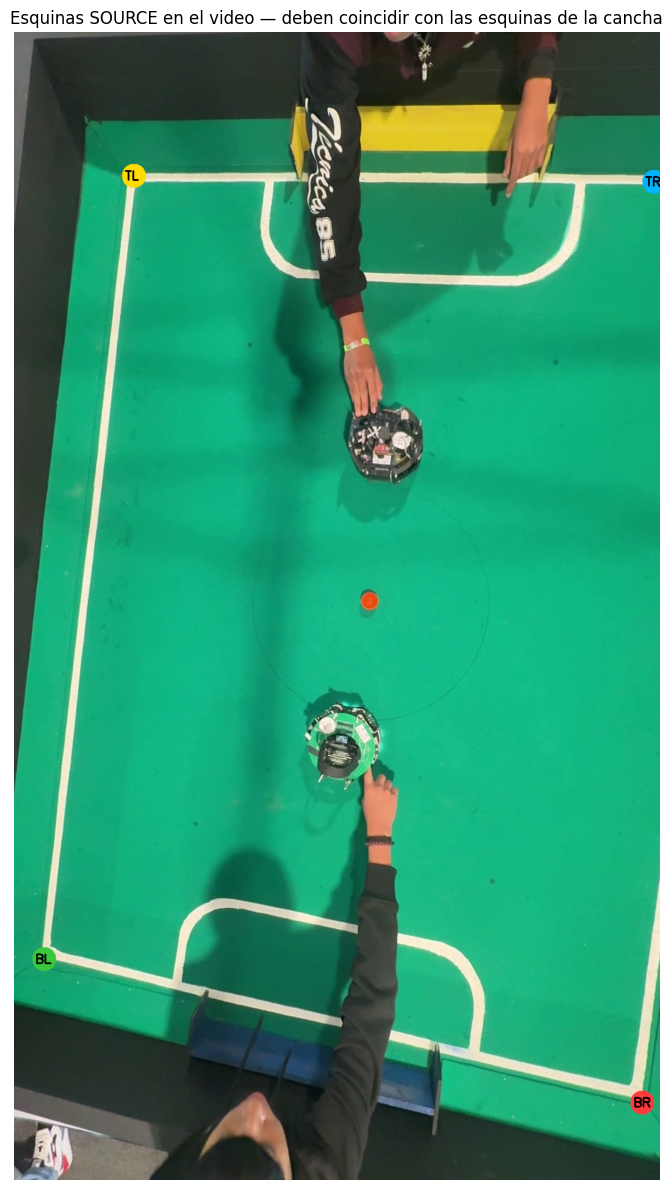

Si los puntos no coinciden con las esquinas, ajusta SOURCE_POINTS en la celda anterior


In [40]:
# Verificar que los puntos SOURCE están bien colocados
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
ret, frame_check = cap.read()
cap.release()

vis = cv2.cvtColor(frame_check, cv2.COLOR_BGR2RGB).copy()
colores_vis = [(255, 220, 0), (0, 180, 255), (255, 60, 60), (60, 200, 60)]
nombres = ["TL", "TR", "BR", "BL"]

for idx, (pt, color, nombre) in enumerate(zip(SOURCE_POINTS, colores_vis, nombres)):
    x, y = int(pt[0]), int(pt[1])
    cv2.circle(vis, (x, y), 20, color, -1)
    cv2.putText(vis, nombre, (x-15, y+7), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 2)

plt.figure(figsize=(8, 12))
plt.imshow(vis)
plt.title("Esquinas SOURCE en el video — deben coincidir con las esquinas de la cancha")
plt.axis("off")
plt.tight_layout()
plt.savefig("assets/verificacion_source_points.png", dpi=100, bbox_inches="tight")
plt.show()
print("Si los puntos no coinciden con las esquinas, ajusta SOURCE_POINTS en la celda anterior")


## 3. Cargar modelos

In [41]:
# ── YucaBot (detector especializado) ──────────────────────────────────────
yolo_model = YOLO("../yucabot.pt")
print(f"✓ YucaBot cargado — clases: {yolo_model.names}")

# ── SAM 3 (segmentador) ────────────────────────────────────────────────────
sam_model = SAM("sam3.pt")
print("✓ SAM 3 cargado")

# ── Anotadores ────────────────────────────────────────────────────────────
mask_annotator  = sv.MaskAnnotator(opacity=0.45)
box_annotator   = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=0.5)
trace_annotator = sv.TraceAnnotator(thickness=2, trace_length=40)

# ── Tracker ───────────────────────────────────────────────────────────────
tracker = sv.ByteTrack()
tracker.reset()

# ── Memoria para interpolación ────────────────────────────────────────────
ultima_det_valida = None
frames_sin_det    = 0
MAX_FRAMES_SIN_DET = 15

print("Todo listo para procesar")


✓ YucaBot cargado — clases: {0: 'ball', 1: 'robot'}
✓ SAM 3 cargado
Todo listo para procesar


## Clasificación de equipos

In [42]:
# ── Clasificación de equipos por primer frame ─────────────────────────────
# Equipo 1 = mitad superior del campo canónico (Y < CAMPO_H/2) → Amarillo
# Equipo 2 = mitad inferior del campo canónico (Y >= CAMPO_H/2) → Azul

TEAM_COLORS_BGR = {
    1: (0,   212, 255),  # Equipo 1 → Amarillo
    2: (255, 100,   0),  # Equipo 2 → Azul
}

In [43]:
# ── project_point va aquí porque clasificar_desde_primer_frame la necesita ──
def project_point(x: float, y: float, H: np.ndarray):
    """Proyecta un punto del video al campo canónico usando la homografía H."""
    pt   = np.float32([[[x, y]]])
    proj = cv2.perspectiveTransform(pt, H)
    return int(proj[0][0][0]), int(proj[0][0][1])

robot_team_map = {}

def clasificar_robot(tracker_id: int, py: int) -> int:
    if tracker_id not in robot_team_map:
        robot_team_map[tracker_id] = 1 if py < CAMPO_H // 2 else 2
    return robot_team_map[tracker_id]


def clasificar_desde_primer_frame(frame: np.ndarray):
    global robot_team_map
    robot_team_map = {}

    res = yolo_model(frame, verbose=False)[0]
    det = sv.Detections.from_ultralytics(res)
    det = det[det.confidence >= 0.50]
    det = det[det.class_id == 1]

    if len(det) == 0:
        print("⚠️ No se detectaron robots en el primer frame — clasificación diferida")
        return

    for i, box in enumerate(det.xyxy):
        cx = (box[0] + box[2]) / 2
        cy = box[3]
        px, py = project_point(cx, cy, H_matrix)
        equipo = 1 if py < CAMPO_H // 2 else 2
        robot_team_map[i + 1] = equipo
        print(f"  Robot {i+1} → Equipo {equipo} (py={py})")

    print(f"✓ Clasificación inicial: {robot_team_map}")


# Ejecutar sobre el primer frame
cap_init = cv2.VideoCapture(VIDEO_PATH)
ret_init, frame_init = cap_init.read()
cap_init.release()

if ret_init:
    clasificar_desde_primer_frame(frame_init)
else:
    print("❌ No se pudo leer el primer frame")

  Robot 1 → Equipo 1 (py=423)
  Robot 2 → Equipo 2 (py=804)
✓ Clasificación inicial: {1: 1, 2: 2}


## Funciones auxiliares

In [44]:
def project_detections(detections: sv.Detections, H: np.ndarray) -> list:
    """Proyecta todas las detecciones al campo canónico."""
    puntos = []
    if len(detections) == 0 or detections.tracker_id is None:
        return puntos

    for box, cid, tid in zip(detections.xyxy, detections.class_id, detections.tracker_id):
        cx = (box[0] + box[2]) / 2
        cy = box[3] if int(cid) == 1 else (box[1] + box[3]) / 2

        px, py = project_point(cx, cy, H)

        # ← determinar equipo para asignar color correcto
        if int(cid) == 1:  # robot
            equipo = clasificar_robot(int(tid), py)
            color  = TEAM_COLORS_BGR[equipo]
        else:              # balón
            equipo = 0
            color  = (0, 200, 255)  # naranja

        puntos.append({
            "pos"       : (px, py),
            "class_id"  : int(cid),
            "tracker_id": int(tid),
            "equipo"    : equipo,
            "color"     : color,
        })
    return puntos


def draw_tactical_canvas(puntos: list, heatmap_acc: np.ndarray = None) -> np.ndarray:
    """Dibuja el mapa táctico con los objetos proyectados."""
    canvas = np.zeros((CAMPO_H, CAMPO_W, 3), dtype=np.uint8)
    canvas[:] = (50, 67, 27)

    # Líneas de la cancha
    cv2.rectangle(canvas, (0, 0), (CAMPO_W-1, CAMPO_H-1), (120, 200, 116), 2)
    cv2.line(canvas, (0, CAMPO_H//2), (CAMPO_W, CAMPO_H//2), (120, 200, 116), 1)
    cv2.circle(canvas, (CAMPO_W//2, CAMPO_H//2), int(30*ESCALA_PX_CM), (120, 200, 116), 1)

    # Porterías con color del equipo que la defiende
    gw = int(60 * ESCALA_PX_CM)
    gx = (CAMPO_W - gw) // 2
    cv2.rectangle(canvas, (gx, 0), (gx+gw, int(8*ESCALA_PX_CM)), TEAM_COLORS_BGR[2], 3)
    cv2.rectangle(canvas, (gx, CAMPO_H-int(8*ESCALA_PX_CM)), (gx+gw, CAMPO_H-1), TEAM_COLORS_BGR[1], 3)

    for p in puntos:
        x, y = p["pos"]
        cid  = p["class_id"]
        tid  = p["tracker_id"]

        if not (0 <= x < CAMPO_W and 0 <= y < CAMPO_H):
            continue

        # ← usar color del equipo en lugar de COLORS_BGR genérico
        color = p["color"]
        r = 18 if cid == 0 else 28

        cv2.circle(canvas, (x, y), r, color, -1)
        cv2.circle(canvas, (x, y), r, (255, 255, 255), 1)
        if cid == 1:
            cv2.putText(canvas, str(tid), (x-8, y+6),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    return canvas


# Acumuladores para heatmap y trails
heatmap_acc   = np.zeros((CAMPO_H, CAMPO_W), dtype=np.float32)
trails_canvas = np.zeros((CAMPO_H, CAMPO_W, 3), dtype=np.uint8)
trails_canvas[:] = (50, 67, 27)
cv2.rectangle(trails_canvas, (0, 0), (CAMPO_W-1, CAMPO_H-1), (120, 200, 116), 2)
cv2.line(trails_canvas, (0, CAMPO_H//2), (CAMPO_W, CAMPO_H//2), (120, 200, 116), 1)

print("✓ Funciones auxiliares definidas")

✓ Funciones auxiliares definidas


## PolygonZone de porterías

In [45]:
import supervision as sv
import numpy as np

# ── Porterías en coordenadas del campo canónico ───────────────────────────
# Portería superior (Equipo 1 defiende) → color Amarillo
# Portería inferior (Equipo 2 defiende) → color Azul

ANCHO_PORTERIA_PX  = int(60 * ESCALA_PX_CM)
GROSOR_PORTERIA_PX      = int(8  * ESCALA_PX_CM)  # para dibujar la portería
GROSOR_GOL_DETECTION_PX = int(25 * ESCALA_PX_CM)  # zona de detección más amplia

porteria_superior_poly = np.array([
    [gx,                     0                        ],
    [gx + ANCHO_PORTERIA_PX, 0                        ],
    [gx + ANCHO_PORTERIA_PX, GROSOR_GOL_DETECTION_PX ],
    [gx,                     GROSOR_GOL_DETECTION_PX ],
], dtype=np.int32)

porteria_inferior_poly = np.array([
    [gx,                     CAMPO_H - GROSOR_GOL_DETECTION_PX],
    [gx + ANCHO_PORTERIA_PX, CAMPO_H - GROSOR_GOL_DETECTION_PX],
    [gx + ANCHO_PORTERIA_PX, CAMPO_H                          ],
    [gx,                     CAMPO_H                          ],
], dtype=np.int32)

# PolygonZone para detección de pelota en portería
zone_superior = sv.PolygonZone(polygon=porteria_superior_poly)
zone_inferior = sv.PolygonZone(polygon=porteria_inferior_poly)

# Contadores de goles
goles_equipo1 = 0  # gol en portería inferior (Equipo 2 defiende)
goles_equipo2 = 0  # gol en portería superior (Equipo 1 defiende)

# Control de cooldown para no contar el mismo gol varias veces
COOLDOWN_FRAMES   = 10
ultimo_gol_frame  = -COOLDOWN_FRAMES

print(f"✓ Porterías configuradas")
print(f"  Superior: x=[{gx}, {gx+ANCHO_PORTERIA_PX}] y=[0, {GROSOR_PORTERIA_PX}]")
print(f"  Inferior: x=[{gx}, {gx+ANCHO_PORTERIA_PX}] y=[{CAMPO_H-GROSOR_PORTERIA_PX}, {CAMPO_H}]")

✓ Porterías configuradas
  Superior: x=[285, 525] y=[0, 32]
  Inferior: x=[285, 525] y=[1048, 1080]


## 5. Pipeline principal

In [46]:
def pipeline_callback_dummy():
    pass  # pipeline ahora está integrado en el loop — ver celda de procesamiento
print("✓ Listo — pipeline integrado en el loop de procesamiento")

✓ Listo — pipeline integrado en el loop de procesamiento


## 6. Procesar video completo

In [ ]:
import time
import openpyxl
from openpyxl import Workbook

# ── Resetear todo ─────────────────────────────────────────────────────────
tracker.reset()
robot_team_map    = {}
heatmap_acc[:]    = 0
trails_canvas[:]  = (50, 67, 27)
cv2.rectangle(trails_canvas, (0, 0), (CAMPO_W-1, CAMPO_H-1), (120, 200, 116), 2)
cv2.line(trails_canvas, (0, CAMPO_H//2), (CAMPO_W, CAMPO_H//2), (120, 200, 116), 1)
ultima_det_valida = None
frames_sin_det    = 0
goles_equipo1     = 0
goles_equipo2     = 0
ultimo_gol_frame  = -COOLDOWN_FRAMES

# ── Excel ─────────────────────────────────────────────────────────────────
wb = Workbook()
ws = wb.active
ws.title = "Tracking"
ws.append([
    "frame", "id_robot", "equipo",
    "x_campo", "y_campo", "area",
    "goles_equipo1", "goles_equipo2",
    "x_ball", "y_ball"
])

# ── Abrir video ───────────────────────────────────────────────────────────
cap          = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps_in       = cap.get(cv2.CAP_PROP_FPS)
vid_w        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
vid_h        = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
ret, frame0 = cap.read()
escala = CAMPO_H / frame0.shape[0]
orig_w = int(frame0.shape[1] * escala)
out_w  = orig_w + CAMPO_W
out_h  = CAMPO_H
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

clasificar_desde_primer_frame(frame0)

print(f"Video entrada : {vid_w}×{vid_h} @ {fps_in:.1f} fps — {total_frames} frames")
print(f"Video salida  : {out_w}×{out_h} px")

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_PIPELINE, fourcc, fps_in, (out_w, out_h))

tiempo_inicio = time.time()
frame_idx     = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # ── YucaBot detecta ───────────────────────────────────────────────────
    yolo_results = yolo_model(frame, verbose=False)[0]
    yolo_det     = sv.Detections.from_ultralytics(yolo_results)
    yolo_det     = yolo_det[yolo_det.confidence >= 0.50]

    if len(yolo_det) > 0:
        # ── SAM 3 en todos los frames ─────────────────────────────────────
        bboxes = yolo_det.xyxy.tolist()
        try:
            sam_results = sam_model(frame, bboxes=bboxes, imgsz=1036, verbose=False)[0]
            sam_det     = sv.Detections.from_ultralytics(sam_results)
        except Exception:
            sam_det = sv.Detections.empty()

        yolo_det  = tracker.update_with_detections(yolo_det)
        usar_sam  = len(sam_det) == len(yolo_det) and len(sam_det) > 0
        det_final = sam_det if usar_sam else yolo_det

        det_final.tracker_id = yolo_det.tracker_id
        det_final.class_id   = yolo_det.class_id
        det_final.confidence = yolo_det.confidence

        ultima_det_valida = det_final
        frames_sin_det    = 0
    else:
        frames_sin_det += 1
        if ultima_det_valida is not None and frames_sin_det <= MAX_FRAMES_SIN_DET:
            det_final = ultima_det_valida
        else:
            resized   = cv2.resize(frame, (orig_w, CAMPO_H))
            tactical  = draw_tactical_canvas([])
            resultado = np.hstack([resized, tactical])
            writer.write(resultado)
            frame_idx += 1
            continue

    # ── Separar robots y balón ────────────────────────────────────────────
    mask_robot = det_final.class_id == 1
    mask_ball  = det_final.class_id == 0
    det_robots = det_final[mask_robot]
    det_ball   = det_final[mask_ball]

    puntos  = []
    ball_px = None
    ball_py = None

    # ── Paso 1: máscaras SAM con color de equipo ──────────────────────────
    annotated = frame.copy()
    if usar_sam and det_final.mask is not None:
        for i, (mask, cid, tid) in enumerate(zip(
            det_final.mask,
            det_final.class_id,
            det_final.tracker_id if det_final.tracker_id is not None
            else range(len(det_final))
        )):
            if int(cid) == 1:  # robot
                equipo    = robot_team_map.get(int(tid), 0)
                color_bgr = TEAM_COLORS_BGR.get(equipo, (255, 255, 255))
            else:              # balón
                color_bgr = (0, 165, 255)

            color_layer = np.zeros_like(annotated)
            color_layer[mask] = color_bgr
            # Solo mezclar donde hay máscara, no en todo el frame
            annotated[mask] = cv2.addWeighted(
                color_layer, 0.4, annotated, 0.6, 0
            )[mask]

    # ── Paso 2: resaltar zonas de portería en el frame ────────────────────
    gh_v = max(1, int(8  * ESCALA_PX_CM * (frame.shape[0] / CAMPO_H)))
    gw_v = max(1, int(60 * ESCALA_PX_CM * (frame.shape[1] / CAMPO_W)))
    gx_v = (frame.shape[1] - gw_v) // 2

    # overlay = annotated.copy()
    # cv2.rectangle(overlay, (gx_v, 0),
    #               (gx_v + gw_v, gh_v),
    #               TEAM_COLORS_BGR[2], -1)
    # cv2.rectangle(overlay,
    #               (gx_v, frame.shape[0] - gh_v),
    #               (gx_v + gw_v, frame.shape[0]),
    #               TEAM_COLORS_BGR[1], -1)
    # annotated = cv2.addWeighted(overlay, 0.35, annotated, 0.65, 0)

    # cv2.rectangle(annotated, (gx_v, 0),
    #               (gx_v + gw_v, gh_v),
    #               TEAM_COLORS_BGR[2], 2)
    # cv2.rectangle(annotated,
    #               (gx_v, frame.shape[0] - gh_v),
    #               (gx_v + gw_v, frame.shape[0]),
    #               TEAM_COLORS_BGR[1], 2)

    # ── Paso 3: procesar robots ───────────────────────────────────────────
    for i in range(len(det_robots)):
        box = det_robots.xyxy[i]
        tid = int(det_robots.tracker_id[i]) if det_robots.tracker_id is not None else i
        cx  = (box[0] + box[2]) / 2
        cy  = box[3]
        px, py = project_point(cx, cy, H_matrix)

        equipo = clasificar_robot(tid, py)
        color  = TEAM_COLORS_BGR[equipo]

        area = None
        if usar_sam and det_robots.mask is not None and i < len(det_robots.mask):
            area = int(det_robots.mask[i].sum())

        puntos.append({
            "pos"       : (px, py),
            "class_id"  : 1,
            "tracker_id": tid,
            "equipo"    : equipo,
            "color"     : color,
        })

        x1, y1, x2, y2 = int(box[0]), int(box[1]), int(box[2]), int(box[3])
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        cv2.putText(annotated, f"E{equipo} #{tid}", (x1, y1 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

        ws.append([
            frame_idx, tid, equipo,
            px, py, area,
            goles_equipo1, goles_equipo2,
            ball_px, ball_py
        ])

    # ── Paso 4: procesar balón ────────────────────────────────────────────
    if len(det_ball) > 0:
        box_b            = det_ball.xyxy[0]
        cx_b             = (box_b[0] + box_b[2]) / 2
        cy_b             = (box_b[1] + box_b[3]) / 2
        ball_px, ball_py = project_point(cx_b, cy_b, H_matrix)

        puntos.append({
            "pos"       : (ball_px, ball_py),
            "class_id"  : 0,
            "tracker_id": 0,
            "equipo"    : 0,
            "color"     : (0, 165, 255),
        })

        x1b, y1b, x2b, y2b = int(box_b[0]), int(box_b[1]), int(box_b[2]), int(box_b[3])
        cv2.rectangle(annotated, (x1b, y1b), (x2b, y2b), (0, 165, 255), 2)
        cv2.putText(annotated, "ball", (x1b, y1b - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 165, 255), 2)

        # ── Detección de gol ──────────────────────────────────────────────
        if (frame_idx - ultimo_gol_frame) > COOLDOWN_FRAMES:
            en_superior = zone_superior.trigger(
                sv.Detections(xyxy=np.array(
                    [[ball_px-5, ball_py-5, ball_px+5, ball_py+5]],
                    dtype=np.float32))
            )
            en_inferior = zone_inferior.trigger(
                sv.Detections(xyxy=np.array(
                    [[ball_px-5, ball_py-5, ball_px+5, ball_py+5]],
                    dtype=np.float32))
            )
            if any(en_superior):
                goles_equipo2    += 1
                ultimo_gol_frame  = frame_idx
                print(f"\nGOL Equipo 2 — frame {frame_idx} | E1:{goles_equipo1} E2:{goles_equipo2}")
            elif any(en_inferior):
                goles_equipo1    += 1
                ultimo_gol_frame  = frame_idx
                print(f"\nGOL Equipo 1 — frame {frame_idx} | E1:{goles_equipo1} E2:{goles_equipo2}")

    # Actualizar coordenadas ball en filas de este frame
    if len(det_robots) > 0:
        for row in ws.iter_rows(min_row=ws.max_row - len(det_robots) + 1,
                                 max_row=ws.max_row):
            row[8].value = ball_px
            row[9].value = ball_py

    # ── Paso 5: trails y heatmap ──────────────────────────────────────────
    for p in puntos:
        x, y = p["pos"]
        if 0 <= x < CAMPO_W and 0 <= y < CAMPO_H:
            cv2.circle(heatmap_acc, (x, y), 10, 1.0, -1)
            cv2.circle(trails_canvas, (x, y), 2, p["color"], -1)

    # ── Paso 6: mapa táctico ──────────────────────────────────────────────
    tactical = draw_tactical_canvas(puntos)

    # ── Paso 7: marcador en video y mapa ─────────────────────────────────
    marcador_txt = f"E1: {goles_equipo1}  |  E2: {goles_equipo2}"

    cv2.rectangle(annotated, (10, 10), (150, 55), (0, 0, 0), -1)
    cv2.putText(annotated, marcador_txt, (18, 43),
                cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 220, 255), 2)

    cv2.rectangle(tactical, (5, 5), (CAMPO_W//4, 50), (0, 0, 0), -1)
    cv2.putText(tactical, marcador_txt, (12, 38),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 220, 255), 2)

    # ── Paso 8: traces ────────────────────────────────────────────────────
    annotated = trace_annotator.annotate(scene=annotated, detections=det_final)

    # ── Paso 9: componer y escribir frame ─────────────────────────────────
    resized   = cv2.resize(annotated, (orig_w, CAMPO_H))
    resultado = np.hstack([resized, tactical])
    writer.write(resultado)

    frame_idx += 1
    if frame_idx % 10 == 0:
        elapsed  = time.time() - tiempo_inicio
        fps_proc = frame_idx / elapsed if elapsed > 0 else 0
        eta_min  = (total_frames - frame_idx) / fps_proc / 60 if fps_proc > 0 else 0
        print(f"Frame {frame_idx:>5}/{total_frames} | "
              f"{fps_proc:.2f} fps | "
              f"ETA: {eta_min:.1f} min", end="\r")

cap.release()
writer.release()

OUTPUT_EXCEL = "assets/tracking_data.xlsx"
wb.save(OUTPUT_EXCEL)

print(f"\n✓ Video guardado : {OUTPUT_PIPELINE}")
print(f"✓ Excel guardado : {OUTPUT_EXCEL}")
print(f"✓ Goles finales  : Equipo 1 = {goles_equipo1} | Equipo 2 = {goles_equipo2}")

  Robot 1 → Equipo 1 (py=423)
  Robot 2 → Equipo 2 (py=804)
✓ Clasificación inicial: {1: 1, 2: 2}
Video entrada : 1080×1920 @ 30.0 fps — 1799 frames
Video salida  : 1417×1080 px
Frame   420/1799 | 0.74 fps | ETA: 30.9 min
GOL Equipo 1 — frame 420 | E1:1 E2:0
Frame  1790/1799 | 0.75 fps | ETA: 0.2 minn
✓ Video guardado : assets/pipeline_final.mp4
✓ Excel guardado : assets/tracking_data.xlsx
✓ Goles finales  : Equipo 1 = 1 | Equipo 2 = 0


## 7. Generar heatmap de actividad

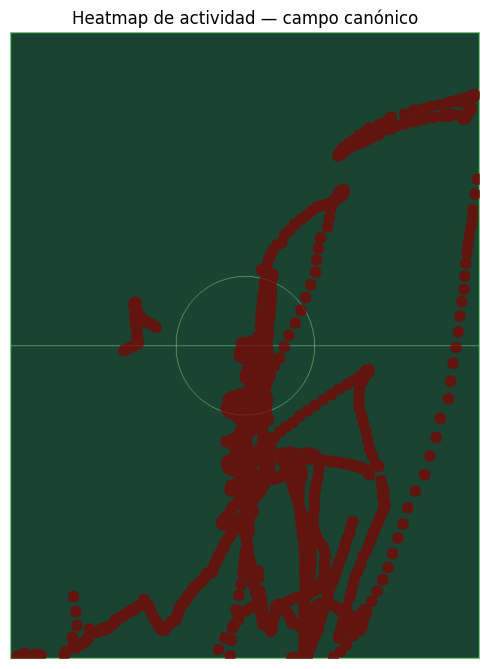

Heatmap guardado: assets/heatmap_final.png


In [49]:
# Normalizar y aplicar colormap al heatmap
heatmap_norm = cv2.normalize(heatmap_acc, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
heatmap_color = cv2.applyColorMap(heatmap_norm, cv2.COLORMAP_JET)

# Superponer sobre el fondo verde de la cancha
campo_fondo = np.zeros((CAMPO_H, CAMPO_W, 3), dtype=np.uint8)
campo_fondo[:] = (50, 67, 27)
cv2.rectangle(campo_fondo, (0, 0), (CAMPO_W-1, CAMPO_H-1), (120, 200, 116), 2)
cv2.line(campo_fondo, (0, CAMPO_H//2), (CAMPO_W, CAMPO_H//2), (120, 200, 116), 1)
cv2.circle(campo_fondo, (CAMPO_W//2, CAMPO_H//2), int(30*ESCALA_PX_CM), (120, 200, 116), 1)

mask_activa = heatmap_norm > 5
heatmap_final = campo_fondo.copy()
heatmap_final[mask_activa] = cv2.addWeighted(
    campo_fondo, 0.3, heatmap_color, 0.7, 0
)[mask_activa]

# Guardar y mostrar
cv2.imwrite(OUTPUT_HEATMAP, heatmap_final)

plt.figure(figsize=(5, 7))
plt.imshow(cv2.cvtColor(heatmap_final, cv2.COLOR_BGR2RGB))
plt.title("Heatmap de actividad — campo canónico")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_HEATMAP.replace(".png", "_plt.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Heatmap guardado: {OUTPUT_HEATMAP}")


## 8. Generar mapa de trayectorias (trails)

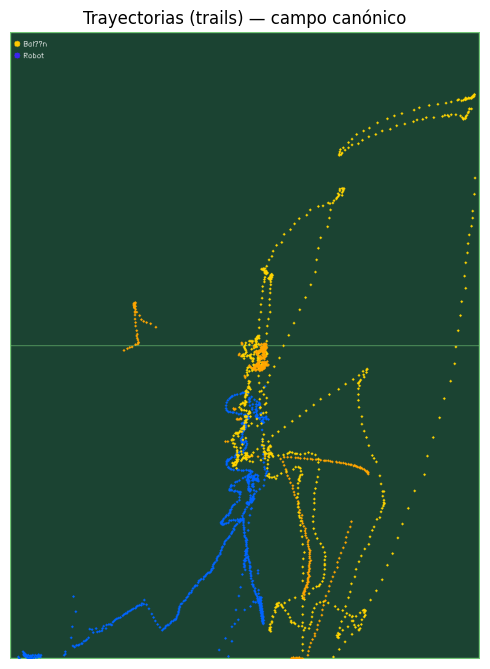

✓ Trails guardado: assets/trails_final.png


In [ ]:
# Añadir leyenda al canvas de trails
leyenda_items = [
    ("Balón",  COLORS_BGR[0]),
    ("Robot",  COLORS_BGR[1]),
]
for i, (nombre, color) in enumerate(leyenda_items):
    y_pos = 20 + i * 20
    cv2.circle(trails_canvas, (12, y_pos), 5, color, -1)
    cv2.putText(trails_canvas, nombre, (22, y_pos+4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

cv2.imwrite(OUTPUT_TRAILS, trails_canvas)

plt.figure(figsize=(5, 7))
plt.imshow(cv2.cvtColor(trails_canvas, cv2.COLOR_BGR2RGB))
plt.title("Trayectorias (trails) — campo canónico")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_TRAILS.replace(".png", "_plt.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Trails guardado: {OUTPUT_TRAILS}")


## 9. Resumen de archivos generados

In [ ]:
import os

archivos = [OUTPUT_PIPELINE, OUTPUT_HEATMAP, OUTPUT_TRAILS]
print("Archivos generados:")
for f in archivos:
    if os.path.exists(f):
        size_mb = os.path.getsize(f) / 1_000_000
        print(f"  ✓ {f} ({size_mb:.1f} MB)")
    else:
        print(f"  ✗ {f} — NO encontrado")

print("")
print("Próximos pasos:")
print("  1. Revisar pipeline_final.mp4 en VLC")
print("  2. Recortar los mejores 2 minutos para el video demo")
print("  3. Hacer el Reel de Instagram (≥30 segundos)")
print("  4. Agregar capturas al README.md")


Archivos generados:
  ✓ assets/pipeline_final.mp4 (31.1 MB)
  ✓ assets/heatmap_final.png (0.0 MB)
  ✓ assets/trails_final.png (0.0 MB)

Próximos pasos:
  1. Revisar pipeline_final.mp4 en VLC
  2. Recortar los mejores 2 minutos para el video demo
  3. Hacer el Reel de Instagram (≥30 segundos)
  4. Agregar capturas al README.md
